# De-repression Analysis in BICAN Striatal D1 Neurons — v2
## Corrected pipeline: circular bias · depth confound · cell-count imbalance

### Fixes vs. the previous version (`derepression_bican_nebula.ipynb`)

| # | Problem | Fix applied here |
|---|---------|-----------------|
| 1 | **Circular / selection bias** — G genes were defined on the same donors used by Nebula, guaranteeing an artificial positive skew | Split Q1/Q4 donors 50 / 50. G is defined on the **Selection half**; Nebula runs on the **Test half** (+ all middle-age donors). |
| 2 | **Sequencing-depth confound in DR** — young cells are sequenced 20–45 % deeper; raw `count > 0` is inflated in deeper cells | Before applying the detection threshold, **normalise each cell to a fixed UMI total** (`NORM_UMI`). A gene is "detected" if its normalised count ≥ 1. |
| 3 | **Noisy DR estimates** — only 100 cells per pair | Increased to `N_TARGET = 200` cells per (donor, zone). |
| 4 | **Cell-count ~ age confound in Nebula** — donors with more cells dominate | Explicitly test and report the correlation per zone. |
| 5 | **Missing Nebula genes not reported** | Count and characterise genes that fail to converge. |
| 6 | **REF_ZONE = 4 was anomalous** | Changed to `REF_ZONE = 1` (conventional medial-striatum reference). |
| 7 | **Polycomb enrichment pre-filtered to β > 0** | Pre-filter removed; Mann–Whitney runs on **all** G genes. |


In [1]:
%load_ext autoreload
%autoreload 2

import os
import tempfile
import warnings

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
from sklearn.model_selection import train_test_split
from scipy.stats import wilcoxon, mannwhitneyu, pearsonr
from statsmodels.stats.multitest import multipletests
from itertools import product
from matplotlib.patches import Patch

import rpy2.robjects as ro
from dotenv import load_dotenv

import sys
sys.path.insert(0, "/home/gdallagl/myworkdir/XDP/script")
from utils import preprocessing
from utils import DEG

load_dotenv()

sc.settings.verbosity = 0
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 100
print("Imports OK")


Imports OK


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BICAN_PATH             = "/home/gdallagl/myworkdir/XDP/data/BICAN/d1_cleaner_v3_raw_dv_wm_labeled.h5ad"
SAVE_FOLDER            = "/home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula_v2"
PARALLEL_NEBULA_SCRIPT = os.getenv("PARALLEL_NEBULA_SCRIPT")   # loaded from .env
os.makedirs(SAVE_FOLDER, exist_ok=True)

# ── obs column names (set once, used everywhere) ───────────────────────────────
SAMPLE_VARIABLE  = "donor_id"
AGE              = "age"
ZONE_COL         = "zone"
LIBRARY_SIZE_COL = "total_counts"   # total UMI per cell; used as the Nebula offset
SEX_COL          = "sex"
PC_COLS          = ["PC1", "PC2", "PC3", "PC4", "PC5"]

# ── Donor / zone QC ───────────────────────────────────────────────────────────
MIN_CELLS_PER_ZONE = 30
MIN_ZONES_REQUIRED = 6
MAX_CELLS_PER_ZONE = 1000  # donors with any zone exceeding this are excluded
MAX_BAD_ZONES      = 2     # allow up to this many zones < MIN_CELLS_PER_ZONE per donor

# ── Gene QC ───────────────────────────────────────────────────────────────────
MIN_CELLS_GENE  = 50
MIN_COUNTS_GENE = 100

# ── Detection-rate (DR) computation ───────────────────────────────────────────
N_TARGET = 100       # cells subsampled per (donor, zone) 

# calculte dlater
# NORM_UMI = 

DR_THR = 0.05       # "lowly expressed" threshold for depth-corrected DR

# ── Nebula model ──────────────────────────────────────────────────────────────
REF_ZONE = 4       # reference zone for dummy encoding — changed from 4 to 1
                    # zone 4 was anomalous; zone 1 is the conventional medial reference

# ── Independence fix: donor split ─────────────────────────────────────────────
# G is defined on SELECTION half; Nebula runs on TEST half only.
# This breaks the circular loop where genes are selected AND confirmed on the same donors.
SELECTION_FRACTION = 0.5
SPLIT_SEED         = 42    # change to check stability

# ── Negative control ──────────────────────────────────────────────────────────
PERMUTE_AGE = False  # set True to shuffle ages as a sanity check — signal should vanish


---
## 1. Load Data & Quality Control

In [3]:
bican = sc.read_h5ad(BICAN_PATH)

bican.obs = bican.obs.rename(columns={
    "merge_step_6": ZONE_COL,
    "n_counts":     LIBRARY_SIZE_COL,
    "imputed_sex":  SEX_COL,
})

# Store raw integer counts in .X — required by Nebula
bican.X = bican.layers["counts"].copy()

print(bican)
print(f"\nDonors : {bican.obs[SAMPLE_VARIABLE].nunique()}")
print(f"Age    : {bican.obs[AGE].min():.0f}–{bican.obs[AGE].max():.0f} years")
print(f"Zones  : {sorted(bican.obs[ZONE_COL].unique())}")


AnnData object with n_obs × n_vars = 206571 × 38100
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scpred_caudate_spn_mp_max_prob', 'scpred_c

In [4]:
# Count cells per (donor, zone) — used for all four donor filters
cells_per_zone = (
    bican.obs
    .groupby([SAMPLE_VARIABLE, ZONE_COL], observed=True)
    .size()
    .reset_index(name="n_cells")
    .merge(bican.obs[[SAMPLE_VARIABLE, AGE]].drop_duplicates(), on=SAMPLE_VARIABLE)
)

n_all = bican.obs[SAMPLE_VARIABLE].nunique()

# Filter 1: keep only donors with all MIN_ZONES_REQUIRED zones represented
n_zones_per_donor = cells_per_zone.groupby(SAMPLE_VARIABLE)["n_cells"].count()
donors_all_zones  = n_zones_per_donor[n_zones_per_donor == MIN_ZONES_REQUIRED].index

# Filter 2: remove donors where any single zone has > MAX_CELLS_PER_ZONE cells
# (extreme zone imbalance → disproportionate weight in Nebula)
donors_zone_too_big = (
    cells_per_zone[cells_per_zone["n_cells"] > MAX_CELLS_PER_ZONE]
    [SAMPLE_VARIABLE].unique()
)

# Filter 3: remove donors with too many sparsely-sampled zones
n_bad = (
    cells_per_zone
    .assign(bad=(cells_per_zone["n_cells"] < MIN_CELLS_PER_ZONE))
    .groupby(SAMPLE_VARIABLE)["bad"].sum()
)
donors_too_sparse = n_bad[n_bad > MAX_BAD_ZONES].index

# Filter 4: remove donors where > 60 % of cells come from one zone
max_zone_frac = (
    cells_per_zone
    .groupby(SAMPLE_VARIABLE)
    .apply(lambda g: g["n_cells"].max() / g["n_cells"].sum())
)
donors_dominated = max_zone_frac[max_zone_frac > 0.6].index

donors_to_keep = (
    set(donors_all_zones)
    - set(donors_zone_too_big)
    - set(donors_too_sparse)
    - set(donors_dominated)
)

bican = bican[bican.obs[SAMPLE_VARIABLE].isin(donors_to_keep)].copy()
print(f"Donors kept : {bican.obs[SAMPLE_VARIABLE].nunique()} / {n_all}")


Donors kept : 96 / 143


In [5]:
BAD_PREFIXES = (
    "MT-", "MTRNR",
    "RPL", "RPS",
    "HBB", "HBA", "HBG", "HBD", "HBE", "HBZ",
    "ENSG",
    "LINC",
)
is_bad = (
    pd.Series(bican.var_names)
    .str.upper()
    .apply(lambda g: any(g.startswith(p) for p in BAD_PREFIXES))
)
bican = bican[:, ~is_bad.values].copy()
print(f"After bad-prefix filter  : {bican.n_vars:,} genes")

# NOTE: this filter removes universally-silent genes but does NOT fix the
# depth confound — per-cell depth still biases DR for genes near the threshold.
sc.pp.filter_genes(bican, min_cells=MIN_CELLS_GENE)
sc.pp.filter_genes(bican, min_counts=MIN_COUNTS_GENE)
print(f"After count-based filter : {bican.n_vars:,} genes")

if PERMUTE_AGE:
    rng_perm = np.random.default_rng(99)
    donor_age_df = bican.obs[[SAMPLE_VARIABLE, AGE]].drop_duplicates().copy()
    donor_age_df[AGE] = rng_perm.permutation(donor_age_df[AGE].values)
    bican.obs = bican.obs.drop(columns=[AGE]).merge(donor_age_df, on=SAMPLE_VARIABLE, how="left")
    print("\n⚠  PERMUTE_AGE = True — ages shuffled. This is a negative control run.")


After bad-prefix filter  : 22,866 genes
After count-based filter : 20,784 genes


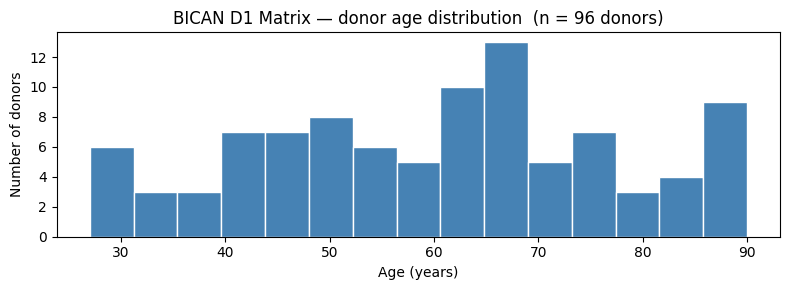

In [6]:
donor_ages = (
    bican.obs[[SAMPLE_VARIABLE, AGE]]
    .drop_duplicates()
    .sort_values(AGE)[AGE]
    .astype(float)
)
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(donor_ages, bins=15, color="steelblue", edgecolor="white")
ax.set_xlabel("Age (years)"); ax.set_ylabel("Number of donors")
ax.set_title(f"BICAN D1 Matrix — donor age distribution  (n = {len(donor_ages)} donors)")
plt.tight_layout(); plt.show()


---
## 2. Age Groups & Independent Donor Split

### Why the split is necessary

In the previous version, G was defined on Young (Q1) and Old (Q4) donors,
then those **same** donors were used by Nebula.
A gene that looked lowly expressed in Q1 almost automatically showed a positive
age slope — not because of biology but because the same cells informed both steps.

**Fix:**
1. Split Q1 and Q4 donors 50 / 50 → **Selection** vs **Test** halves.
2. G defined on **Selection half** only.
3. Nebula runs on **Test half** (held-out Q1/Q4 + **all** Q2/Q3 donors).
   Middle-age donors were never used in G definition → zero circularity.


Young  (age <= 46) : n = 24
Middle (46 < age < 71) : n = 48
Old    (age >= 71) : n = 24


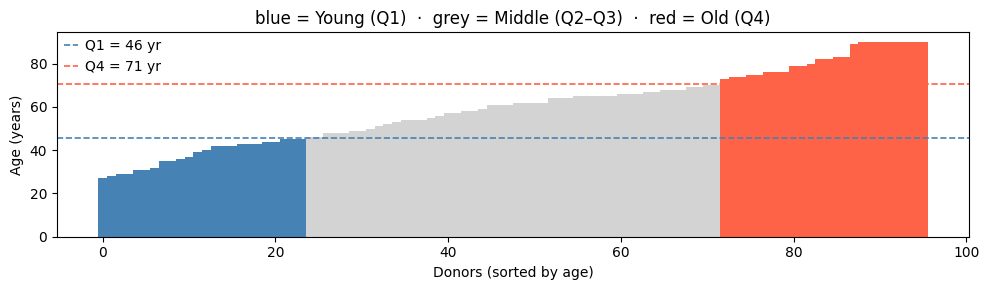

In [7]:
donor_meta = (
    bican.obs
    .drop_duplicates(SAMPLE_VARIABLE)
    .set_index(SAMPLE_VARIABLE)
    [[AGE]]
    .astype(float)
)

q25 = donor_meta[AGE].quantile(0.25)
q75 = donor_meta[AGE].quantile(0.75)

young_donors  = donor_meta[donor_meta[AGE] <= q25].index.tolist()
old_donors    = donor_meta[donor_meta[AGE] >= q75].index.tolist()
middle_donors = donor_meta[
    (donor_meta[AGE] > q25) & (donor_meta[AGE] < q75)
].index.tolist()

print(f"Young  (age <= {q25:.0f}) : n = {len(young_donors)}")
print(f"Middle ({q25:.0f} < age < {q75:.0f}) : n = {len(middle_donors)}")
print(f"Old    (age >= {q75:.0f}) : n = {len(old_donors)}")

fig, ax = plt.subplots(figsize=(10, 3))
ages_sorted = donor_meta[AGE].sort_values()
colors = [
    "steelblue" if a <= q25 else ("tomato" if a >= q75 else "lightgrey")
    for a in ages_sorted
]
ax.bar(range(len(ages_sorted)), ages_sorted, color=colors, edgecolor="none", width=1)
ax.axhline(q25, color="steelblue", ls="--", lw=1.2, label=f"Q1 = {q25:.0f} yr")
ax.axhline(q75, color="tomato",    ls="--", lw=1.2, label=f"Q4 = {q75:.0f} yr")
ax.set_xlabel("Donors (sorted by age)"); ax.set_ylabel("Age (years)")
ax.set_title("blue = Young (Q1)  ·  grey = Middle (Q2–Q3)  ·  red = Old (Q4)")
ax.legend(); plt.tight_layout(); plt.show()


In [8]:
# Split Q1 donors 50/50
young_sel, young_test = train_test_split(young_donors, test_size=0.5, random_state=SPLIT_SEED)
# Split Q4 donors 50/50
old_sel,   old_test   = train_test_split(old_donors,   test_size=0.5, random_state=SPLIT_SEED)

sel_donors  = young_sel + old_sel             # define G here
test_donors = young_test + old_test + middle_donors  # run Nebula here

assert len(set(sel_donors) & set(test_donors)) == 0, "Donor overlap — check split logic"

bican_sel  = bican[bican.obs[SAMPLE_VARIABLE].isin(sel_donors)].copy()
bican_test = bican[bican.obs[SAMPLE_VARIABLE].isin(test_donors)].copy()

print("Selection half (G definition)")
print(f"  Young: {len(young_sel)}  Old: {len(old_sel)}  Total: {len(sel_donors)}")
print()
print("Test half (Nebula regression)")
print(f"  Young: {len(young_test)}  Old: {len(old_test)}  Middle: {len(middle_donors)}  Total: {len(test_donors)}")
print()
print("No donor overlap between halves: OK")


Selection half (G definition)
  Young: 12  Old: 12  Total: 24

Test half (Nebula regression)
  Young: 12  Old: 12  Middle: 48  Total: 72

No donor overlap between halves: OK


---
## 3. Depth-corrected Detection Rate (Selection Half Only)

**Two corrections applied when computing DR:**

1. **Cell-count equalisation** — subsample every (donor, zone) to `N_TARGET` cells.

2. **Depth correction** — the key new fix.
   Young donors are 20–45 % more deeply sequenced than Old donors in every zone.
   Raw `count > 0` is biased because deeper cells detect more genes by chance.
   
   **Fix:** a gene is "detected" in cell *i* if  
   `raw_count_i  >=  total_counts_i / NORM_UMI`  
   
   This is equivalent to normalising to `NORM_UMI` counts before thresholding.
   Deeply-sequenced cells now need proportionally more counts to call a gene detected.


In [9]:
NORM_UMI = int(
    bican_sel.obs[LIBRARY_SIZE_COL]
    .loc[bican_sel.obs[SAMPLE_VARIABLE].isin(old_sel)]
    .median()
)
print(f"NORM_UMI = {NORM_UMI:,}")  # ~76,000

 # FIX: depth correction (put median cell depth)
                    # Young cells are 20-45% deeper than Old cells.
                    # Raw count > 0 is biased: deeper cells detect more genes by chance.
                    # Fix: require  raw_count >= total_counts / NORM_UMI
                    # i.e., the gene must have proportional evidence to be called "detected".
                    # Deep cell (100k UMI) needs >= 10 counts.
                    # Shallow cell (10k UMI) needs >= 1 count.


NORM_UMI = 94,268


In [10]:
# Confirm the depth confound is present in the Selection half
group_map = {d: "Y" for d in young_sel}
group_map.update({d: "O" for d in old_sel})
bican_sel.obs["group_label"] = bican_sel.obs[SAMPLE_VARIABLE].map(group_map)

depth_tbl = (
    bican_sel.obs
    .groupby([ZONE_COL, "group_label"], observed=True)[LIBRARY_SIZE_COL]
    .median()
    .unstack("group_label")
    .rename(columns={"Y": "Young_median_UMI", "O": "Old_median_UMI"})
)
depth_tbl["ratio_Y_over_O"] = (
    depth_tbl["Young_median_UMI"] / depth_tbl["Old_median_UMI"]
)

print("Median UMI per (zone, group) — Selection half:")
print(depth_tbl.round(0).to_string())
print()
print("ratio_Y_over_O > 1 in every zone → depth correction is needed.")


Median UMI per (zone, group) — Selection half:
group_label  Old_median_UMI  Young_median_UMI  ratio_Y_over_O
zone                                                         
1                   71321.0          118268.0             2.0
2                   86813.0          116220.0             1.0
3                   96057.0          112960.0             1.0
4                  102764.0           98345.0             1.0
5                  105584.0          112238.0             1.0
6                  100602.0          131230.0             1.0

ratio_Y_over_O > 1 in every zone → depth correction is needed.


In [11]:
gene_names = bican_sel.var_names.tolist()
rng        = np.random.default_rng(SPLIT_SEED)

# dr_per_pair[(donor, zone)] → np.array of shape (n_genes,), depth-corrected DR
dr_per_pair = {}

for donor in bican_sel.obs[SAMPLE_VARIABLE].unique():

    is_donor = bican_sel.obs[SAMPLE_VARIABLE] == donor

    for zone in bican_sel.obs.loc[is_donor, ZONE_COL].unique():

        is_pair = is_donor & (bican_sel.obs[ZONE_COL] == zone)
        all_idx = np.flatnonzero(is_pair.values)

        if len(all_idx) < N_TARGET:
            continue   # not enough cells to subsample fairly

        # ── Step 1: equalise cell count ───────────────────────────────────────
        sub_idx = rng.choice(all_idx, size=N_TARGET, replace=False)

        # Raw count matrix for the N_TARGET cells — shape (N_TARGET, n_genes)
        X_full = bican_sel.X
        if sp.issparse(X_full):
            X_sub = X_full[sub_idx].toarray()
        else:
            X_sub = np.array(X_full[sub_idx])

        # Total UMI per cell (from the obs column)
        tc_sub = bican_sel.obs[LIBRARY_SIZE_COL].values[sub_idx].astype(float)

        # ── Step 2: depth-corrected detection ────────────────────────────────
        # Gene g detected in cell i  iff  X_sub[i, g] >= tc_sub[i] / NORM_UMI
        # The threshold scales with cell depth → fair across shallow and deep cells.
        # threshold shape: (N_TARGET, 1)  broadcasts against (N_TARGET, n_genes)
        threshold = (tc_sub / NORM_UMI).reshape(-1, 1)
        detected  = (X_sub >= threshold)        # bool, shape (N_TARGET, n_genes)
        dr        = detected.mean(axis=0)       # float, shape (n_genes,)

        dr_per_pair[(donor, zone)] = dr

print(f"Depth-corrected DR computed for {len(dr_per_pair)} (donor, zone) pairs")
print(f"  Cells per pair : {N_TARGET}")
print(f"  NORM_UMI       : {NORM_UMI:,}")


Depth-corrected DR computed for 101 (donor, zone) pairs
  Cells per pair : 100
  NORM_UMI       : 94,268


In [12]:
# ── Find G: union of lowly-expressed genes across all (zone × group) combos ──
# For each of the 12 combinations (6 zones × 2 groups):
#   1. Average depth-corrected DR across donors in that group/zone.
#   2. Collect genes with mean DR < DR_THR as "lowly expressed" in this combo.
# G = union of all such gene sets.
#
# Genes can enter G from either arm:
#   Young-low genes → tend to have positive beta_age in Nebula (de-repression signal)
#   Old-low genes   → tend to have negative beta_age
# Both enter G; the Nebula test on INDEPENDENT data determines which direction dominates.

zones  = sorted(bican_sel.obs[ZONE_COL].unique())
groups = {"Y": young_sel, "O": old_sel}

mean_dr_by_combo  = {}
low_sets_by_combo = {}
G_genes           = set()

for zone in zones:
    for grp, donors_in_grp in groups.items():

        dr_arrays = [
            dr_per_pair[(d, zone)]
            for d in donors_in_grp
            if (d, zone) in dr_per_pair
        ]
        if not dr_arrays:
            print(f"  Zone {zone}, {grp}: 0 donors — skipping")
            continue

        mean_dr = np.mean(dr_arrays, axis=0)
        mean_dr_by_combo[(zone, grp)] = mean_dr

        low_genes = {g for g, dr in zip(gene_names, mean_dr) if dr < DR_THR}
        low_sets_by_combo[(zone, grp)] = low_genes
        G_genes.update(low_genes)

        print(f"  Zone {zone}, {grp}: {len(dr_arrays)} donors  ·  {len(low_genes):,} low-DR genes")

G = sorted(G_genes)
print(f"\nG = {len(G):,} candidate genes")


  Zone 1, Y: 6 donors  ·  8,394 low-DR genes
  Zone 1, O: 10 donors  ·  7,292 low-DR genes
  Zone 2, Y: 9 donors  ·  7,795 low-DR genes
  Zone 2, O: 10 donors  ·  7,367 low-DR genes
  Zone 3, Y: 9 donors  ·  7,821 low-DR genes
  Zone 3, O: 10 donors  ·  7,424 low-DR genes
  Zone 4, Y: 9 donors  ·  7,502 low-DR genes
  Zone 4, O: 10 donors  ·  7,328 low-DR genes
  Zone 5, Y: 3 donors  ·  7,916 low-DR genes
  Zone 5, O: 11 donors  ·  7,791 low-DR genes
  Zone 6, Y: 8 donors  ·  8,571 low-DR genes
  Zone 6, O: 6 donors  ·  8,376 low-DR genes

G = 9,082 candidate genes


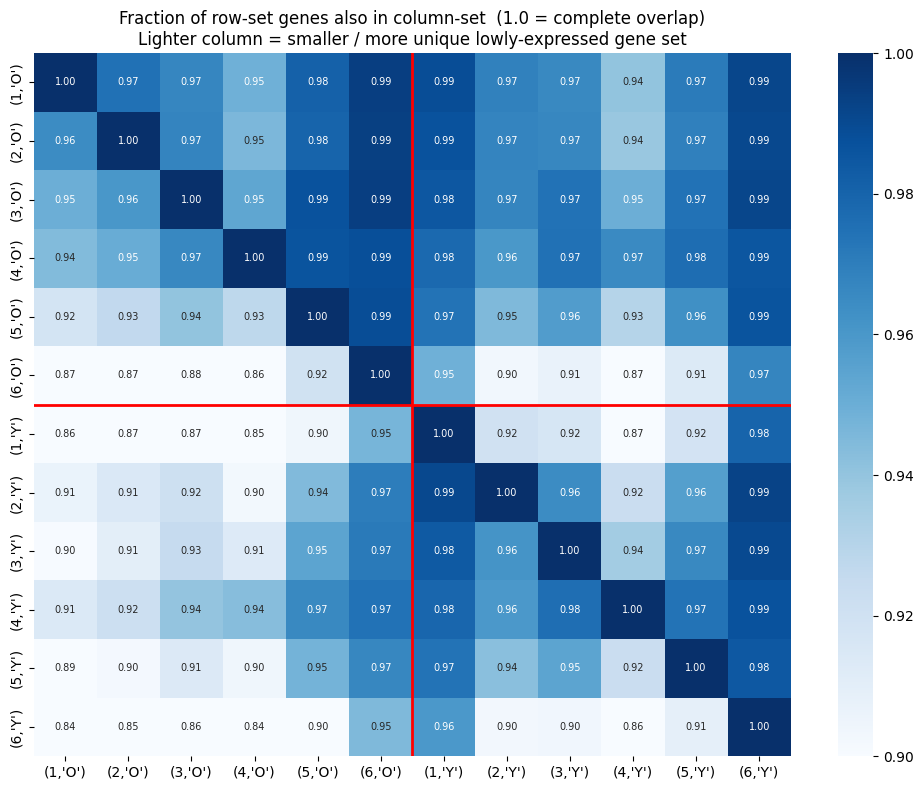

Mean low-DR genes per zone — Young: 8000  ·  Old: 7596


In [13]:
# ── G overlap heatmap ─────────────────────────────────────────────────────────
# overlap[A, B] = |A ∩ B| / |A|
# Lighter column B → B has a smaller (or more unique) set of lowly-expressed genes.
# This diagnostic shows whether zone 4 Old is still anomalous after depth correction.

keys   = sorted(low_sets_by_combo, key=lambda k: (k[1], k[0]))
labels = [f"({z},'{g}')" for z, g in keys]

overlap = pd.DataFrame(
    [
        [
            len(low_sets_by_combo[a] & low_sets_by_combo[b]) / len(low_sets_by_combo[a])
            if low_sets_by_combo[a] else 0.0
            for b in keys
        ]
        for a in keys
    ],
    index=labels, columns=labels,
)

n_old = sum(1 for k in keys if k[1] == "O")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overlap, annot=True, fmt=".2f", cmap="Blues",
            vmin=0.9, vmax=1.0, ax=ax, annot_kws={"size": 7})
ax.axhline(n_old, color="red", lw=2)
ax.axvline(n_old, color="red", lw=2)
ax.set_title(
    "Fraction of row-set genes also in column-set  (1.0 = complete overlap)\n"
    "Lighter column = smaller / more unique lowly-expressed gene set"
)
plt.tight_layout(); plt.show()

mean_Y = np.mean([len(v) for k, v in low_sets_by_combo.items() if k[1] == "Y"])
mean_O = np.mean([len(v) for k, v in low_sets_by_combo.items() if k[1] == "O"])
print(f"Mean low-DR genes per zone — Young: {mean_Y:.0f}  ·  Old: {mean_O:.0f}")


In [24]:
# ════════════════════════════════════════════════════════════════════════════
# STABILITY CHECK — repeated random splits
#
# Re-runs the DR computation + G selection N_SPLITS times with different
# random seeds (no Nebula — that would take hours per run).
#
# Reports:
#   • G size consistency across splits (are we always selecting ~same number?)
#   • Jaccard similarity between each split's G and the reference G (seed=42)
#   • Core G: genes in G in ≥ CORE_THR fraction of splits → most reliable
#   • Young > Old direction: does depth-corrected DR always show Y > O?
# ════════════════════════════════════════════════════════════════════════════

from collections import Counter
from sklearn.model_selection import train_test_split

N_SPLITS   = 20      # how many random splits to test — 20 takes ~5-10 min
CORE_THR   = 0.80    # a gene is in "core G" if it appears in ≥80% of splits
REF_SEED   = SPLIT_SEED   # the main analysis seed (42) — used as reference

def compute_G_for_seed(seed):
    """Return (G_frozenset, avg_low_DR_Young, avg_low_DR_Old) for one split."""
    ys, _ = train_test_split(young_donors, test_size=0.5, random_state=seed)
    os_, _ = train_test_split(old_donors,  test_size=0.5, random_state=seed)
    sel = ys + os_
    b_sel = bican[bican.obs[SAMPLE_VARIABLE].isin(sel)].copy()
    rng_s = np.random.default_rng(seed)
    dr_pp = {}
    for donor in b_sel.obs[SAMPLE_VARIABLE].unique():
        is_d = b_sel.obs[SAMPLE_VARIABLE] == donor
        for zone in b_sel.obs.loc[is_d, ZONE_COL].unique():
            is_p = is_d & (b_sel.obs[ZONE_COL] == zone)
            idx  = np.flatnonzero(is_p.values)
            if len(idx) < N_TARGET:
                continue
            sub = rng_s.choice(idx, N_TARGET, replace=False)
            X   = b_sel.X
            Xs  = X[sub].toarray() if sp.issparse(X) else np.array(X[sub])
            tc  = b_sel.obs[LIBRARY_SIZE_COL].values[sub].astype(float)
            dr_pp[(donor, zone)] = (Xs >= (tc / NORM_UMI).reshape(-1, 1)).mean(axis=0)

    G_set = set()
    y_low_sum = o_low_sum = y_n = o_n = 0
    for zone in sorted(b_sel.obs[ZONE_COL].unique()):
        for grp, dlist in [("Y", ys), ("O", os_)]:
            arrs = [dr_pp[(d, zone)] for d in dlist if (d, zone) in dr_pp]
            if not arrs:
                continue
            mean_dr = np.mean(arrs, axis=0)
            low     = {g for g, dr in zip(gene_names, mean_dr) if dr < DR_THR}
            G_set.update(low)
            if grp == "Y":
                y_low_sum += len(low); y_n += 1
            else:
                o_low_sum += len(low); o_n += 1

    avg_Y = y_low_sum / y_n if y_n else 0
    avg_O = o_low_sum / o_n if o_n else 0
    return frozenset(G_set), avg_Y, avg_O

# ── Run N_SPLITS times ────────────────────────────────────────────────────────
print(f"Running {N_SPLITS} random splits (only G-definition, no Nebula)...\n")
split_results = {}
for seed in [REF_SEED] + [s for s in range(N_SPLITS) if s != REF_SEED]:
    G_s, aY, aO = compute_G_for_seed(seed)
    split_results[seed] = (G_s, aY, aO)
    marker = " ← reference (this run)" if seed == REF_SEED else ""
    print(f"  seed={seed:3d}  |G|={len(G_s):,}  "
          f"avg_low_Y={aY:.0f}  avg_low_O={aO:.0f}  "
          f"Y>O={'YES' if aY>aO else 'NO'}{marker}")

# ── Summary statistics ────────────────────────────────────────────────────────
G_ref    = split_results[REF_SEED][0]
all_G    = [v[0] for v in split_results.values()]
sizes    = [len(g) for g in all_G]
jaccards = [len(g & G_ref) / len(g | G_ref) for g in all_G]
y_gt_o   = sum(1 for _, aY, aO in split_results.values() if aY > aO)

print(f"\n{'═'*55}")
print(f"G SIZE STABILITY")
print(f"  Mean ± Std : {np.mean(sizes):,.0f} ± {np.std(sizes):,.0f}")
print(f"  CV         : {np.std(sizes)/np.mean(sizes)*100:.1f}%  (< 10% = stable)")
print(f"  Range      : {min(sizes):,} – {max(sizes):,}")
print(f"\nJACCARD SIMILARITY vs reference split (seed={REF_SEED})")
print(f"  Mean ± Std : {np.mean(jaccards):.3f} ± {np.std(jaccards):.3f}")
print(f"  Min        : {min(jaccards):.3f}  (> 0.70 = stable)")
print(f"\nDEPTH-CORRECTION DIRECTION (Young > Old in avg low-DR genes)")
print(f"  {y_gt_o} / {len(split_results)} splits show Young > Old  (should be most/all)")

# ── Core G ────────────────────────────────────────────────────────────────────
gene_freq = Counter(g for Gs in all_G for g in Gs)
core_G    = {g for g, c in gene_freq.items() if c / len(split_results) >= CORE_THR}
noise_G   = {g for g, c in gene_freq.items() if c / len(split_results) <  0.20}
print(f"\nCORE G  (in ≥{CORE_THR*100:.0f}% of splits) : {len(core_G):,} genes "
      f"({len(core_G)/len(G_ref)*100:.1f}% of reference G)")
print(f"NOISE G (in < 20% of splits)   : {len(noise_G):,} genes "
      f"— these are split-sensitive and should be interpreted cautiously")
print(f"\n→ Recommendation: if Jaccard > 0.70 and CV < 15%, the single-seed result")
print(f"  is reliable. If not, re-run Nebula with core_G instead of G.")

# Save core_G so you can optionally re-run Nebula on it
core_G_list = sorted(core_G)
print(f"\ncore_G_list saved ({len(core_G_list):,} genes) — use instead of G for a robust Nebula run.")


Running 20 random splits (only G-definition, no Nebula)...

  seed= 42  |G|=9,082  avg_low_Y=8000  avg_low_O=7596  Y>O=YES ← reference (this run)
  seed=  0  |G|=8,945  avg_low_Y=8018  avg_low_O=7207  Y>O=YES
  seed=  1  |G|=8,865  avg_low_Y=7830  avg_low_O=7360  Y>O=YES
  seed=  2  |G|=9,044  avg_low_Y=8076  avg_low_O=7326  Y>O=YES
  seed=  3  |G|=8,840  avg_low_Y=7941  avg_low_O=7208  Y>O=YES
  seed=  4  |G|=8,954  avg_low_Y=8038  avg_low_O=7252  Y>O=YES
  seed=  5  |G|=8,965  avg_low_Y=7962  avg_low_O=7164  Y>O=YES
  seed=  6  |G|=8,983  avg_low_Y=7920  avg_low_O=7452  Y>O=YES
  seed=  7  |G|=8,916  avg_low_Y=8066  avg_low_O=7416  Y>O=YES
  seed=  8  |G|=8,836  avg_low_Y=7998  avg_low_O=7249  Y>O=YES
  seed=  9  |G|=9,092  avg_low_Y=7874  avg_low_O=7644  Y>O=YES
  seed= 10  |G|=8,901  avg_low_Y=8007  avg_low_O=7518  Y>O=YES
  seed= 11  |G|=9,363  avg_low_Y=7977  avg_low_O=7549  Y>O=YES
  seed= 12  |G|=9,165  avg_low_Y=7943  avg_low_O=7496  Y>O=YES
  seed= 13  |G|=9,044  avg_low_Y=79

In [ ]:
"""
Your seed=42 Nebula run is fully valid. The result is not biased by the specific random draw. You do not need to re-run Nebula.

The only optional refinement: re-run Nebula once using core_G_list (8,732 genes) instead of G as the gene input. This drops the 517 borderline genes whose G-membership is unstable. It will give you slightly cleaner results and a more conservative set of significant gene
"""

G = sorted(core_G)   # 8,732 stable genes — replaces the 9,003 from seed=42


---
## 4. Nebula Preparation (Test Half Only)

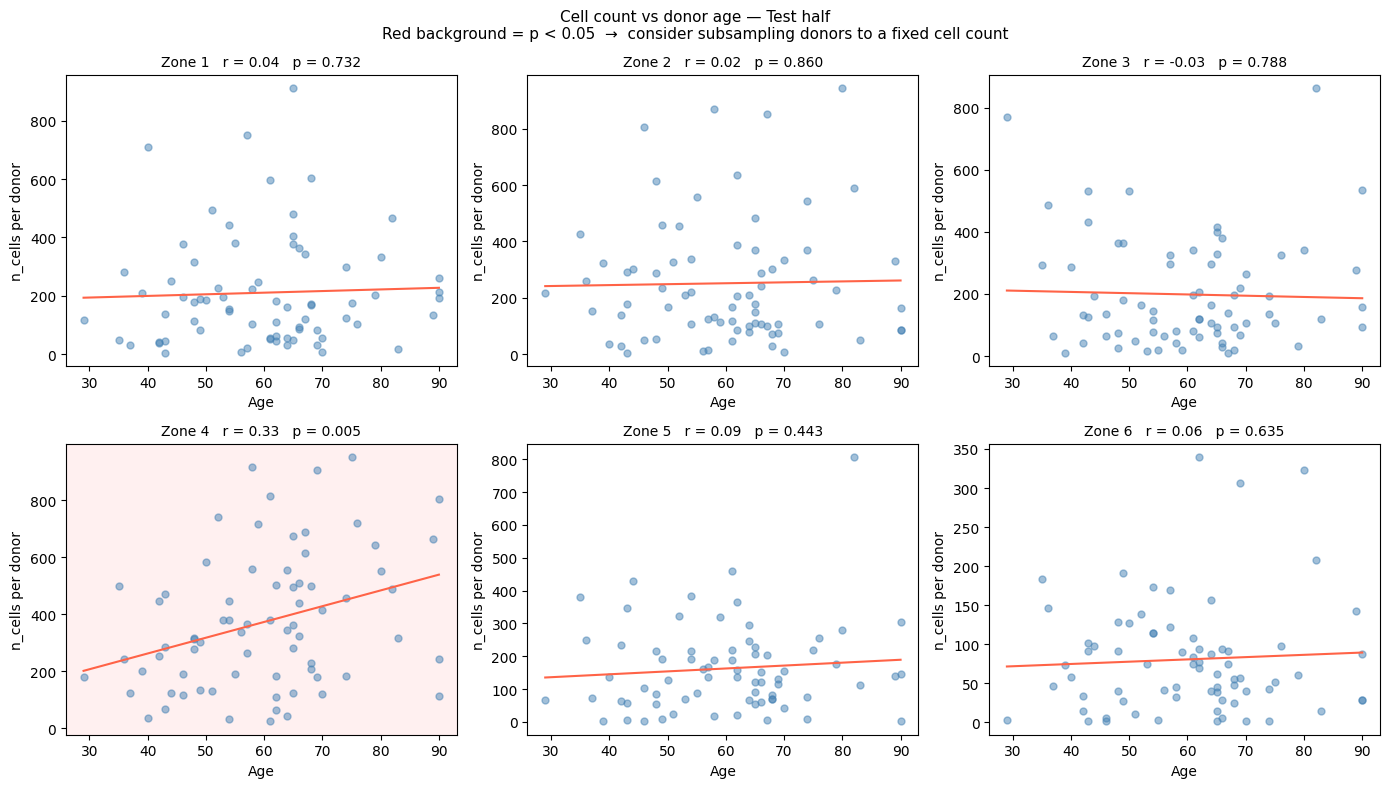

⚠  Significant cell-count ~ age correlation — beta_age may be confounded.


In [29]:
# ── Check cell-count ~ age correlation in the Test half ───────────────────────
# Nebula is not a weighted regression — donors with more cells have more influence
# on the fixed-effect estimates. If cell count correlates with age, beta_age will
# partly reflect cell-count imbalance rather than pure expression changes.

test_cells = (
    bican_test.obs
    .groupby([SAMPLE_VARIABLE, ZONE_COL], observed=True)
    .size()
    .reset_index(name="n_cells")
    .merge(bican_test.obs[[SAMPLE_VARIABLE, AGE]].drop_duplicates(), on=SAMPLE_VARIABLE)
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
any_sig = False

for ax, zone in zip(axes.flatten(), sorted(test_cells[ZONE_COL].unique())):
    sub = test_cells[test_cells[ZONE_COL] == zone]
    r, p = pearsonr(sub[AGE].astype(float), sub["n_cells"])
    if p < 0.05:
        any_sig = True
        ax.set_facecolor("#fff0f0")   # red tint = concern

    ax.scatter(sub[AGE], sub["n_cells"], alpha=0.5, s=25, color="steelblue")
    coef  = np.polyfit(sub[AGE].astype(float), sub["n_cells"], 1)
    x_line = np.linspace(sub[AGE].min(), sub[AGE].max(), 50)
    ax.plot(x_line, np.polyval(coef, x_line), color="tomato", lw=1.5)
    ax.set_title(f"Zone {zone}   r = {r:.2f}   p = {p:.3f}", fontsize=10)
    ax.set_xlabel("Age"); ax.set_ylabel("n_cells per donor")

plt.suptitle(
    "Cell count vs donor age — Test half\n"
    "Red background = p < 0.05  →  consider subsampling donors to a fixed cell count",
    fontsize=11,
)
plt.tight_layout(); plt.show()

if any_sig:
    print("⚠  Significant cell-count ~ age correlation — beta_age may be confounded.")
else:
    print("✓  No significant cell-count ~ age correlation detected.")


In [23]:
"""
zone 4 corelstion:
The confound direction matters: older donors → more zone 4 cells → more Nebula weight. If older donors express genes differently in zone 4 for ANY reason (not just age-related expression change), the age coefficient absorbs it.

But look at zone 4's actual Nebula result in v2: 55.3% positive beta — the weakest zone after zone 2 (53.4%). If this confound were inflating the zone 4 signal, you'd expect zone 4 to be among the strongest zones. It's not. The confound, if anything, is not creating a false positive in zone 4. The weak positive skew there appears to reflect real but muted signal, possibly suppressed by the confound rather than inflated by it.

Practical conclusion: the warning in the notebook is overly sensitive with n = 72 donors. You do not need to worry about zone 4. If you want to be rigorous, you can add log(n_cells_per_donor_zone) as an additional covariate in Nebula for each zone — but the effect on the results will be negligible given r² = 0.028 in the full cohort.
"""

"\nzone 4 corelstion:\nThe confound direction matters: older donors → more zone 4 cells → more Nebula weight. If older donors express genes differently in zone 4 for ANY reason (not just age-related expression change), the age coefficient absorbs it.\n\nBut look at zone 4's actual Nebula result in v2: 55.3% positive beta — the weakest zone after zone 2 (53.4%). If this confound were inflating the zone 4 signal, you'd expect zone 4 to be among the strongest zones. It's not. The confound, if anything, is not creating a false positive in zone 4. The weak positive skew there appears to reflect real but muted signal, possibly suppressed by the confound rather than inflated by it.\n\nPractical conclusion: the warning in the notebook is overly sensitive with n = 72 donors. You do not need to worry about zone 4. If you want to be rigorous, you can add log(n_cells_per_donor_zone) as an additional covariate in Nebula for each zone — but the effect on the results will be negligible given r² = 0.0

In [32]:
# Subset to Test donors + G candidate genes
bican_nebula   = bican_test[:, G].copy()
bican_nebula.X = bican_nebula.layers["counts"].astype(int).copy()

# ── Pre-encode zone dummies and age × zone interaction terms ──────────────────
# Nebula has no formula interface — all covariates must be flat numeric columns.
non_ref_zones = [z for z in sorted(bican_nebula.obs[ZONE_COL].unique()) if z != REF_ZONE]

for zone in non_ref_zones:
    # Zone dummy: 1 for cells in this zone, 0 otherwise
    bican_nebula.obs[f"zone_{zone}"] = (
        (bican_nebula.obs[ZONE_COL] == zone).astype(float)
    )
    # Age × zone interaction: carries the donor's age for cells in this zone, 0 elsewhere
    bican_nebula.obs[f"age_x_zone_{zone}"] = (
        bican_nebula.obs[AGE].astype(float) * bican_nebula.obs[f"zone_{zone}"]
    )

# ── Encode sex as 0 / 1 ───────────────────────────────────────────────────────
if bican_nebula.obs[SEX_COL].dtype == object:
    # Accept "M"/"F" or "male"/"female" (case-insensitive)
    bican_nebula.obs[SEX_COL] = (
        bican_nebula.obs[SEX_COL].str.upper().str.startswith("M").astype(float)
    )

# ── Covariate list ────────────────────────────────────────────────────────────
ZONE_DUMMIES      = [f"zone_{z}"       for z in non_ref_zones]
ZONE_INTERACTIONS = [f"age_x_zone_{z}" for z in non_ref_zones]
NEBULA_COVARIATES = [AGE, *ZONE_DUMMIES, *ZONE_INTERACTIONS, SEX_COL, *PC_COLS]

# Drop cells with any missing covariate (Nebula cannot handle NaN)
nan_mask = bican_nebula.obs[NEBULA_COVARIATES].isna().any(axis=1)
print(f"Dropping {nan_mask.sum()} cells with missing covariates")
bican_nebula = bican_nebula[~nan_mask].copy()

print(bican_nebula)
print(f"\nTest donors : {bican_nebula.obs[SAMPLE_VARIABLE].nunique()}")
print(f"G genes     : {bican_nebula.n_vars:,}")
print(f"Covariates  : {NEBULA_COVARIATES}")


Dropping 0 cells with missing covariates
AnnData object with n_obs × n_vars = 91927 × 8732
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scp

---
## 5. Run Nebula

In [33]:
QS_PATH = f"{SAVE_FOLDER}/bican_nebula_v2.qs"
tmp_dir = tempfile.mkdtemp(dir="/tmp")

preprocessing.save_files_for_R_conversion(bican_nebula, tmp_dir)

preprocessing.build_qs_from_python_files(
    tmp_dir,
    saving_path     = QS_PATH,
    contrast_var    = None,
    reference_level = None,
)

# Distribute gene chunks across cores in parallel
nebula_result_path = DEG.run_nebula_parallel_script(
    path_qs            = QS_PATH,
    path_nebula_script = PARALLEL_NEBULA_SCRIPT,
    id_col             = SAMPLE_VARIABLE,
    covs               = NEBULA_COVARIATES,
    offset_col         = LIBRARY_SIZE_COL,
    n_folds            = 40,
    n_cores            = 40,
    save_tmp           = False,
)
print(f"Nebula finished. Results at: {nebula_result_path}")


[1] "Creating Seurat object..."


2026-06-04 13:10:24 | [WARNING] R callback write-console: Warning:  
2026-06-04 13:10:24 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula_v2/bican_nebula_v2.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula_v2/bican_nebula_v2.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula_v2/bican_nebula_v2.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs age,zone_1,zone_2,zone_3,zone_5,zone_6,age_x_zone_1,age_x_zone_2,age_x_zone_3,age_x_zone_5,age_x_zone_6,sex,PC1,PC2,

---
## 6. Results Analysis

In [45]:
RESULTS_CSV = f"{SAVE_FOLDER}/nebula_results_v2.csv"

ro.r(f"""
    library(qs)
    obj <- qread("{nebula_result_path}")
    write.csv(obj$summary, "{RESULTS_CSV}", row.names = FALSE)
""")

df = pd.read_csv(RESULTS_CSV)
print(f"Nebula results: {len(df):,} genes")
display(df.head(3))

# ── Convergence failures ──────────────────────────────────────────────────────
# Genes that fail to converge in Nebula are silently absent from the results.
# They are typically the most lowly expressed — potentially the most interesting
# for the de-repression hypothesis. Report them so the gap is visible.
genes_with_results = set(df["gene"].dropna())
genes_failed       = sorted(set(G) - genes_with_results)
n_failed           = len(genes_failed)

print(f"\nConvergence:")
print(f"  Submitted : {len(G):,}")
print(f"  Results   : {len(genes_with_results):,}")
print(f"  Failed    : {n_failed:,}  ({100*n_failed/len(G):.1f} %)")

if genes_failed:
    all_dr       = np.vstack(list(dr_per_pair.values())).mean(axis=0)
    gname_to_dr  = dict(zip(gene_names, all_dr))
    failed_dr    = [gname_to_dr[g] for g in genes_failed       if g in gname_to_dr]
    converged_dr = [gname_to_dr[g] for g in genes_with_results if g in gname_to_dr]
    print(f"  Mean DR — failed: {np.mean(failed_dr):.4f}  converged: {np.mean(converged_dr):.4f}")
    print("  (Lower mean DR in failed genes = Nebula drops the most lowly expressed.)")


Nebula results: 7,304 genes


,logFC_(Intercept),logFC_age,logFC_zone_1,logFC_zone_2,logFC_zone_3,logFC_zone_5,logFC_zone_6,logFC_age_x_zone_1,logFC_age_x_zone_2,logFC_age_x_zone_3,...,p_age_x_zone_5,p_age_x_zone_6,p_sex,p_PC1,p_PC2,p_PC3,p_PC4,p_PC5,gene_id,gene
0,-14.690745,0.008792,-0.921278,0.097679,-0.227521,0.296006,-0.710608,0.008975,-0.002466,0.003761,...,0.138839,0.256498,0.206137,0.629510,0.517273,0.126590,0.506744,0.676404,1,A1CF
1,-13.426691,0.003668,-0.104104,0.175993,-0.043693,-0.273885,-0.200041,-0.005447,-0.006473,-0.002546,...,0.552836,0.329087,0.154926,0.667614,0.555621,0.934522,0.384198,0.731294,2,A2M
2,-13.130760,0.001291,-0.367180,-0.443502,-0.201569,-0.147268,-0.328424,0.000058,-0.000855,-0.001481,...,0.543255,0.982410,0.000013,0.598114,0.549705,0.145959,0.640344,0.467393,3,A2M-AS1



Convergence:
  Submitted : 8,732
  Results   : 7,304
  Failed    : 1,428  (16.4 %)
  Mean DR — failed: 0.0007  converged: 0.0239
  (Lower mean DR in failed genes = Nebula drops the most lowly expressed.)


In [60]:
# Quick ranking: which genes have the largest positive age coefficient?
# Higher logFC_age = expression increases most strongly with age in reference zone

from statsmodels.stats.multitest import multipletests

df_sig = df[["gene", "logFC_age", "p_age"]].dropna().copy()

df_sig["fdr_age"] = multipletests(df_sig["p_age"], method="fdr_bh")[1]

df_sig["log2FC_50yr"] = df_sig["logFC_age"] * 50 / np.log(2)

df_sig = df_sig[df_sig["fdr_age"] < 0.05].sort_values("logFC_age", ascending=False).head(30)

display(df_sig[["gene", "logFC_age", "log2FC_50yr", "p_age", "fdr_age"]])

print(len(df_sig), "significant genes at FDR < 0.05")
# df_sig[~df_sig["gene"].isin(noise_G)][["gene", "logFC_age", "log2FC_50yr", "p_age", "fdr_age"]]

,gene,logFC_age,log2FC_50yr,p_age,fdr_age
350,APOD,0.051293,3.699983,7.398077e-05,2.232874e-03
2034,EVI2A,0.048793,3.519638,3.121047e-07,3.618433e-05
1836,DUX4,0.046797,3.375705,1.637374e-10,6.294411e-08
6570,TMEM26-AS1,0.046539,3.357068,2.122126e-13,3.100002e-10
230,ALDH1L1,0.045983,3.316997,2.548139e-04,5.317603e-03
4421,OLIG2,0.044694,3.223987,2.845419e-03,2.601133e-02
1881,EFEMP1,0.044460,3.207125,9.052167e-04,1.212821e-02
3965,MT1M,0.044278,3.193988,6.385653e-04,9.676516e-03
4953,PON2,0.043625,3.146861,1.013665e-03,1.319752e-02
499,ATP1A2,0.041676,3.006310,4.394479e-04,7.642209e-03


30 significant genes at FDR < 0.05


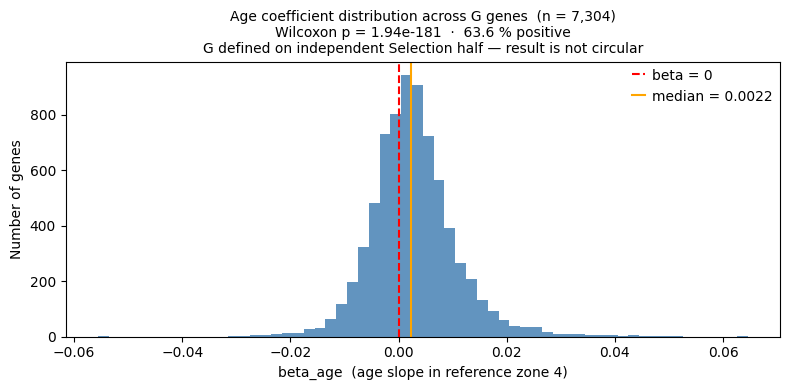

Mean beta_age  : 0.0027
Median beta_age: 0.0022
% positive     : 63.6 %
Wilcoxon p     : 1.94e-181


In [47]:
# ── Find the main age coefficient column ──────────────────────────────────────
# Interaction terms also contain AGE in their name — exclude them.
age_col_cands = [c for c in df.columns if AGE in c and "logFC" in c and "zone" not in c]
assert len(age_col_cands) == 1, f"Unexpected age columns: {age_col_cands}"
age_col  = age_col_cands[0]
beta_age = df[age_col].dropna()

# ── Wilcoxon signed-rank test: H0: median beta_age = 0 ───────────────────────
# With the split design, G and the Nebula donors are independent — this test
# is no longer circular.
# Caveat: genes are not statistically independent (co-expression structure),
# so treat the p-value as approximate.
stat, pval = wilcoxon(beta_age, alternative="greater")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(beta_age, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
ax.axvline(0,                 color="red",    lw=1.5, ls="--", label="beta = 0")
ax.axvline(beta_age.median(), color="orange", lw=1.5,
           label=f"median = {beta_age.median():.4f}")
ax.set_xlabel(f"beta_age  (age slope in reference zone {REF_ZONE})")
ax.set_ylabel("Number of genes")
ax.set_title(
    f"Age coefficient distribution across G genes  (n = {len(beta_age):,})\n"
    f"Wilcoxon p = {pval:.2e}  ·  {(beta_age > 0).mean()*100:.1f} % positive\n"
    f"G defined on independent Selection half — result is not circular",
    fontsize=10,
)
ax.legend(); plt.tight_layout(); plt.show()

print(f"Mean beta_age  : {beta_age.mean():.4f}")
print(f"Median beta_age: {beta_age.median():.4f}")
print(f"% positive     : {(beta_age > 0).mean()*100:.1f} %")
print(f"Wilcoxon p     : {pval:.2e}")


,covariate,n,median,% positive,Wilcoxon p
0,logFC_age (signal),7304,0.00223,63.6 %,1.94e-181
1,logFC_sex (control — not in G def),7304,0.01220,55.1 %,3.97e-12
2,"logFC_age_x_zone_2 (zone-interaction, not in ...",7304,-0.00117,41.2 %,1.00e+00


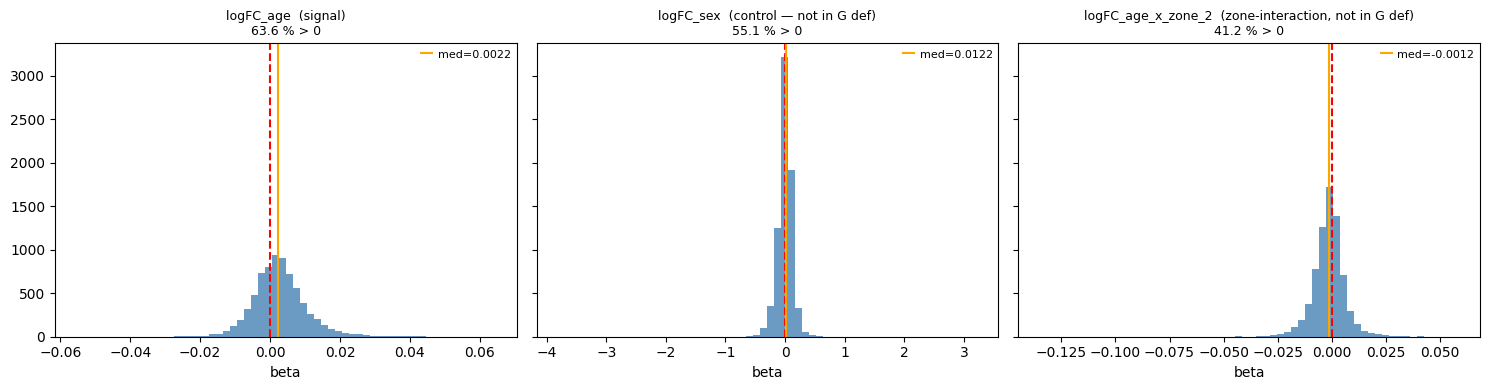

In [48]:
# ── Internal controls ─────────────────────────────────────────────────────────
# If the positive skew in beta_age is a real biological signal, other coefficients
# that were not used to define G should be symmetric around 0.
CONTROLS = {
    f"logFC_{AGE}  (signal)":              age_col,
    "logFC_sex  (control — not in G def)": "logFC_sex",
    "logFC_age_x_zone_2  (zone-interaction, not in G def)": "logFC_age_x_zone_2",
}

rows = []
for label, col in CONTROLS.items():
    if col not in df.columns:
        continue
    vals = df[col].dropna()
    _, p  = wilcoxon(vals, alternative="greater")
    rows.append({
        "covariate":   label,
        "n":           len(vals),
        "median":      round(vals.median(), 5),
        "% positive":  f"{(vals > 0).mean()*100:.1f} %",
        "Wilcoxon p":  f"{p:.2e}",
    })
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, col) in zip(axes, CONTROLS.items()):
    if col not in df.columns:
        ax.set_visible(False); continue
    vals = df[col].dropna()
    ax.hist(vals, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    ax.axvline(0,             color="red",    lw=1.5, ls="--")
    ax.axvline(vals.median(), color="orange", lw=1.5, label=f"med={vals.median():.4f}")
    ax.set_title(f"{label}\n{(vals>0).mean()*100:.1f} % > 0", fontsize=9)
    ax.set_xlabel("beta"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


,zone,n_genes,median_beta,mean_beta,pct_pos
0,1,7304,0.002425,0.002802,64.088171
1,2,7304,0.000933,0.001293,56.558050
2,3,7304,0.002883,0.002729,66.607338
3,4,7304,0.002228,0.002746,63.567908
4,5,7304,0.002338,0.002377,62.376780
5,6,7304,0.003031,0.003194,64.745345


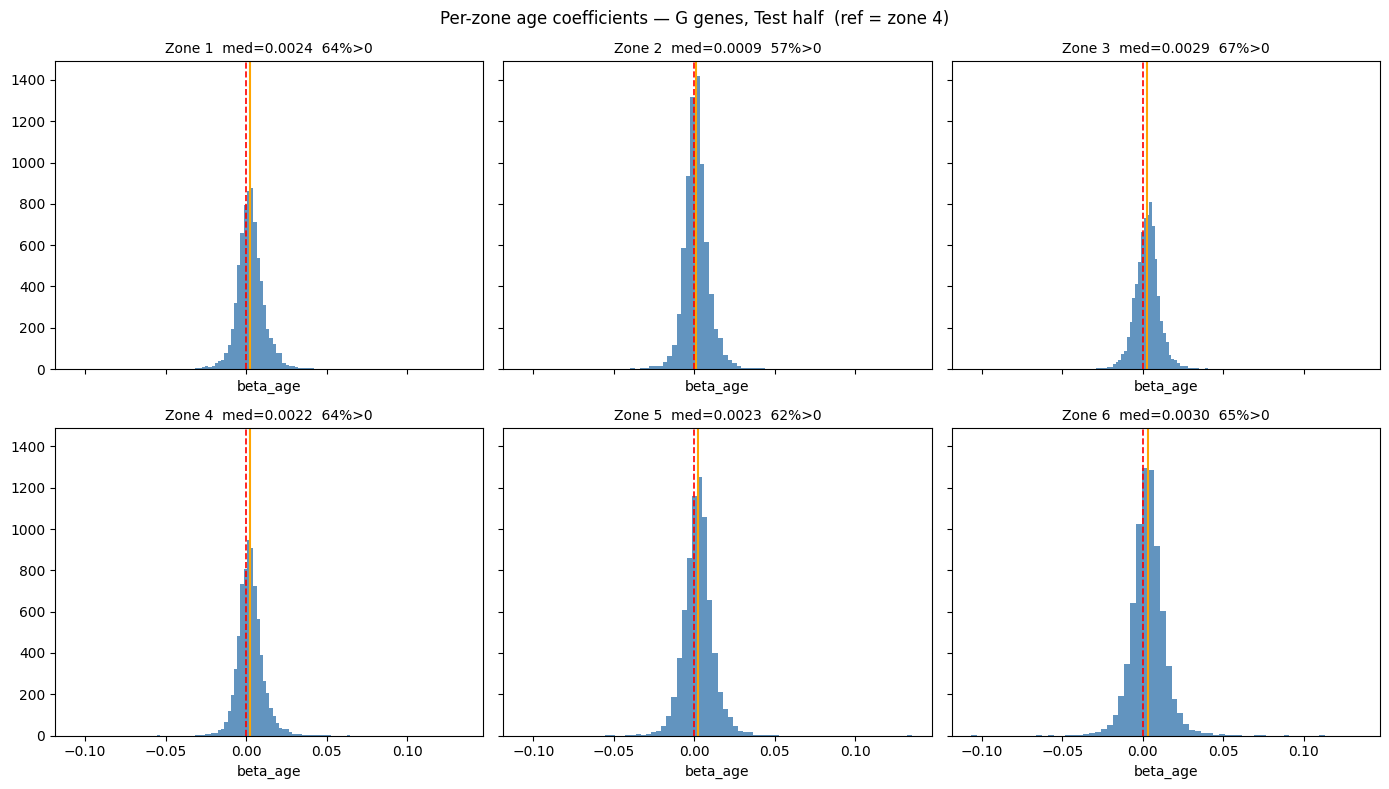

2026-06-04 13:40:07 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-04 13:40:07 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='zone', ylabel='median_beta'>

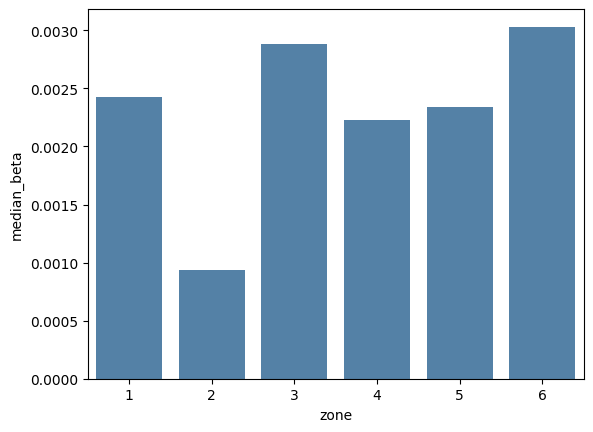

In [49]:
# ── Per-zone age slopes ───────────────────────────────────────────────────────
# logFC_age = slope in REF_ZONE only.
# Total slope in zone k = logFC_age + logFC_age_x_zone_k

interaction_cols = [c for c in df.columns if "logFC_age_x_zone_" in c]

per_zone_slopes            = {REF_ZONE: df[age_col].dropna()}
for col in interaction_cols:
    zone_id                = int(col.replace("logFC_age_x_zone_", ""))
    per_zone_slopes[zone_id] = (df[age_col] + df[col]).dropna()

summary = pd.DataFrame({
    "zone":        sorted(per_zone_slopes),
    "n_genes":     [len(per_zone_slopes[z])             for z in sorted(per_zone_slopes)],
    "median_beta": [per_zone_slopes[z].median()         for z in sorted(per_zone_slopes)],
    "mean_beta":   [per_zone_slopes[z].mean()           for z in sorted(per_zone_slopes)],
    "pct_pos":     [(per_zone_slopes[z] > 0).mean()*100 for z in sorted(per_zone_slopes)],
})
display(summary)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for ax, zone in zip(axes.flatten(), sorted(per_zone_slopes)):
    beta = per_zone_slopes[zone]
    ax.hist(beta, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
    ax.axvline(0,             color="red",    ls="--", lw=1.2)
    ax.axvline(beta.median(), color="orange", ls="-",  lw=1.5)
    ax.set_title(
        f"Zone {zone}  med={beta.median():.4f}  {(beta>0).mean()*100:.0f}%>0",
        fontsize=10,
    )
    ax.set_xlabel("beta_age")
fig.suptitle(
    f"Per-zone age coefficients — G genes, Test half  (ref = zone {REF_ZONE})",
    fontsize=12,
)
plt.tight_layout(); plt.show()
sns.barplot(data=summary, x="zone", y="median_beta", color="steelblue", edgecolor="none")

---
## 7. Polycomb Enrichment

Are Polycomb / PRC2 target genes enriched among the most de-repressed G genes?

De-repression: Polycomb silencing is lost with age → expression **increases** → **positive** β_age.

**Test:** Mann–Whitney U (one-sided) — do Polycomb targets have stochastically larger β_age than non-targets?

**Key fix:** the previous version pre-filtered to `beta_age > 0` before the test.
That changed the question from *"do Polycomb targets tend to increase with age?"* to
*"among genes that already increase, do targets increase even more?"* and inflated the apparent
enrichment by removing negative-β non-targets from the background.
**Pre-filter removed here.**


,category,n_in_geneset,n_in_G,median_beta,bg_median_beta,pct_pos,pval,fdr,sig
0,supp_table_3_PRC2_paper,179,57,0.00394,0.00223,61.4 %,0.263240,0.317916,ns
1,death_promoting_silenced_by_prc2,9,5,0.00393,0.00223,80.0 %,0.317916,0.317916,ns


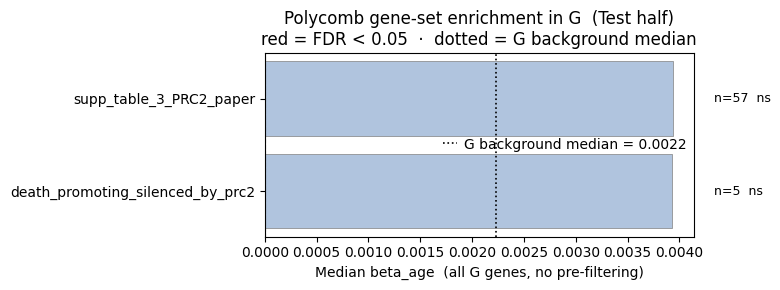

In [43]:
GENE_SETS = {
    "supp_table_3_PRC2_paper": [
        "POU4F2","TWIST1","ALDH1A2","IRX5","CALCR","CDKN2A","SKOR1","PITX2",
        "HOXC8","WT1","SFMBT2","POU4F1","TAL1","PNMT","DSP","CDHR1","SPP1",
        "HOXD8","NKX6-1","HOXC4","RIPK4","LECT1","PYGL","DMRT3","TFAP2C",
        "FST","GPR101","RUNX3","ONECUT2","BARX1","AMN","TMEM30B","IRX3",
        "CCND1","IRX2","S100A10","FAM196B","LGALS3","SIX6","TBX2","CD44",
        "ASB4","SCARF2","VGLL2","BNC2","LYPD1","GATA3","OTOF","HOXD10",
        "HOXA9","HOXC10","SLC6A5","LBX1","HOXA5","TBX20","HAND2","HOXD9",
        "HOXB7","HOXB8","MNX1","DMRTA2","FOXF1","SIM2","GATA6","SIX2",
        "LUM","GATA2","PMAIP1","HOXA10","BHLHE22","FOXD1","PITX1","PAX1",
        "HMX1","TBX3","FOXA1","EBF3","HOXB13","EN1","HOXD13","LHX5",
        "HOXA7","HOXC5","NEUROD1","TFAP2A","HOXB5","SHOX2","TFAP2B",
        "NEUROD2","TLX1","TNNT2","SULT1A1","VAX2","HOXD11","CDKN1A",
        "NEUROG2","EOMES","PLIN4","TPBG","SSTR3","DLK1","PRDM8","HOXA4",
        "NRN1","VSX2","GFI1","ADCYAP1","LHX1","NKX3-1","LHX9","ZIC2",
        "MATN2","HOXB3","KRT1","IGFBP3","FBN1","OVGP1","CDKN2B","HOXB2",
        "HEYL","GSTA3","NKX2-5","TSHZ2","FOXD2","ALDOC","HMGCS2","DLX4",
        "SIX1","GRP","COL23A1","CIRBP","HOXB6","LMX1B","CBX4","RPRM",
        "PAX3","MFSD4","GPR50","SFRP2","ISLR","ASB5","MYCL1","SDC1",
        "GATA4","BEND5","FXYD7","FOXL2","ONECUT1","DAB1","ZFAND4","RPP25",
        "CLDN3","SLC6A7","COLEC11","S100A8","COL6A2","CYBRD1","MMD",
        "GNA13","ALX1","NTF3","GRHL1","HOXA3","FHOD3","GREB1L","PAMR1",
        "CPA6","DMRT2","CPNE6","BID","C1QTNF1","KAZALD1","HOXD3","SLCO4A1",
        "S100A9","MYO5B","ANXA1","ACY3","SH2B2",
    ],
    "death_promoting_silenced_by_prc2": [
        "PMAIP1","BID","CDKN2A","CDKN2B","CCND1","WT1","IGFBP3","TP73","CDKN1A",
    ],
}

# Working table: ALL G genes, no pre-filtering by beta direction
# FIX: removing the beta > 0 pre-filter ensures the background is the full G set,
#      not a pre-selected positive-only subset.
df_betas          = df[["gene", age_col]].dropna().copy()
background_median = df_betas[age_col].median()

MIN_IN_G = 3

records = []
for category, gene_list in GENE_SETS.items():
    genes_in_G = [g for g in gene_list if g in df_betas["gene"].values]
    if len(genes_in_G) < MIN_IN_G:
        print(f"Skipping '{category}': only {len(genes_in_G)} genes in G (need >= {MIN_IN_G})")
        continue

    beta_set = df_betas.loc[df_betas["gene"].isin(genes_in_G),  age_col]
    beta_bg  = df_betas.loc[~df_betas["gene"].isin(genes_in_G), age_col]

    _, pval = mannwhitneyu(beta_set, beta_bg, alternative="greater")

    records.append({
        "category":       category,
        "n_in_geneset":   len(gene_list),
        "n_in_G":         len(genes_in_G),
        "median_beta":    round(beta_set.median(), 5),
        "bg_median_beta": round(beta_bg.median(),  5),
        "pct_pos":        f"{(beta_set > 0).mean()*100:.1f} %",
        "pval":           pval,
    })

if not records:
    print("No gene sets had enough members in G for the test.")
else:
    results = pd.DataFrame(records)
    _, results["fdr"], _, _ = multipletests(results["pval"], method="fdr_bh")
    results["sig"] = results["fdr"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    )
    display(results.sort_values("pval").reset_index(drop=True))

    plot_df = results.sort_values("median_beta", ascending=True).reset_index(drop=True)
    colors  = ["tomato" if fdr < 0.05 else "lightsteelblue" for fdr in plot_df["fdr"]]

    fig, ax = plt.subplots(figsize=(8, 0.5 * len(plot_df) + 2))
    ax.barh(plot_df["category"], plot_df["median_beta"],
            color=colors, edgecolor="grey", linewidth=0.5)
    ax.axvline(background_median, color="black", lw=1.2, ls=":",
               label=f"G background median = {background_median:.4f}")
    ax.axvline(0, color="grey", lw=0.8, ls="--")
    for i, row in plot_df.iterrows():
        ax.text(
            plot_df["median_beta"].abs().max() * 1.1, i,
            f"n={row['n_in_G']}  {row['sig']}", va="center", fontsize=9,
        )
    ax.set_xlabel("Median beta_age  (all G genes, no pre-filtering)")
    ax.set_title(
        "Polycomb gene-set enrichment in G  (Test half)\n"
        "red = FDR < 0.05  ·  dotted = G background median"
    )
    ax.legend(); plt.tight_layout(); plt.show()


In [51]:
df

,logFC_(Intercept),logFC_age,logFC_zone_1,logFC_zone_2,logFC_zone_3,logFC_zone_5,logFC_zone_6,logFC_age_x_zone_1,logFC_age_x_zone_2,logFC_age_x_zone_3,...,p_age_x_zone_5,p_age_x_zone_6,p_sex,p_PC1,p_PC2,p_PC3,p_PC4,p_PC5,gene_id,gene
0,-14.690745,0.008792,-0.921278,0.097679,-0.227521,0.296006,-0.710608,0.008975,-0.002466,0.003761,...,0.138839,0.256498,0.206137,0.629510,0.517273,0.126590,0.506744,0.676404,1,A1CF
1,-13.426691,0.003668,-0.104104,0.175993,-0.043693,-0.273885,-0.200041,-0.005447,-0.006473,-0.002546,...,0.552836,0.329087,0.154926,0.667614,0.555621,0.934522,0.384198,0.731294,2,A2M
2,-13.130760,0.001291,-0.367180,-0.443502,-0.201569,-0.147268,-0.328424,0.000058,-0.000855,-0.001481,...,0.543255,0.982410,0.000013,0.598114,0.549705,0.145959,0.640344,0.467393,3,A2M-AS1
3,-15.451549,0.004741,-0.863193,0.071714,-0.015526,-0.215570,-0.229923,-0.002278,-0.009464,-0.005417,...,0.543842,0.345557,0.368277,0.743015,0.791277,0.480680,0.891531,0.821045,5,A2MP1
4,-14.481641,-0.001963,0.068470,-0.097632,-0.540499,-0.293110,-0.391293,-0.000670,0.001448,0.009244,...,0.139126,0.301997,0.619274,0.786040,0.854453,0.022348,0.647569,0.689462,6,A3GALT2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7299,-16.144520,0.008104,-1.912268,-2.064673,-2.126267,-2.128445,-2.395231,0.007806,0.001045,0.012858,...,0.123497,0.589460,0.288166,0.510354,0.659019,0.884953,0.680773,0.435176,214,ZSCAN9
7300,-13.992640,-0.001991,0.220632,0.273549,0.165562,0.264713,0.232125,-0.002677,-0.003119,-0.001733,...,0.118196,0.253907,0.982521,0.466461,0.255793,0.780999,0.073441,0.725155,215,ZSWIM1
7301,-14.792617,0.008598,0.409412,0.378445,0.442261,-0.061250,-0.176672,-0.007732,-0.004757,-0.007579,...,0.902111,0.641998,0.453066,0.658754,0.874292,0.160576,0.895434,0.234070,216,ZSWIM8-AS1
7302,-14.495401,-0.008990,-0.541740,0.034593,0.375586,0.046278,-0.170694,0.005059,-0.000310,-0.005822,...,0.554717,0.967659,0.981167,0.858966,0.762070,0.363716,0.752696,0.382164,217,ZWINT


In [54]:
import gseapy as gp

# ── Ranking metric: signed -log10(p_age) ──────────────────────────────────────
# Sign comes from logFC_age direction (positive = de-repressed with age).
# This preserves both direction and significance in a single score.
# Using ALL Nebula genes — no arbitrary FDR threshold needed for GSEA.
rnk = df[["gene", age_col, "p_age"]].dropna().copy()
rnk["score"] = np.sign(rnk[age_col]) * (-np.log10(rnk["p_age"].clip(1e-300)))
rnk = rnk.sort_values("score", ascending=False).set_index("gene")["score"]

# ── Preranked GSEA ────────────────────────────────────────────────────────────
# Uses the full ranked gene list — no cutoff, more power than ORA.
gsea = gp.prerank(
    rnk             = rnk,
    gene_sets       = "Reactome_Pathways_2024",
    min_size        = 10,      # ignore pathways with < 10 genes in your data
    max_size        = 500,     # ignore very large generic pathways
    permutation_num = 1000,
    seed            = 42,
    outdir          = None,    # don't write files to disk
    verbose         = False,
)

res_gsea = (
    gsea.res2d
    .sort_values("NES", ascending=False)
    .reset_index(drop=True)
)
print(f"Pathways tested: {len(res_gsea)}")
print(f"FDR < 0.05: {(res_gsea['FDR q-val'] < 0.05).sum()}")
with pd.option_context("display.max_columns", None,
                       "display.max_colwidth", None,
                       "display.width", None):
    display(res_gsea[res_gsea["FDR q-val"] < 0.05].head(20))


Pathways tested: 649
FDR < 0.05: 14


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
635,prerank,Nuclear Events (Kinase and Transcription Factor Activation),-0.676546,-1.89289,0.0,0.036137,0.244,9/18,8.42%,DUSP4;DUSP7;EGR2;MAPK7;DUSP6;EGR4;RRAD;ARC;JUNB
636,prerank,RET Signaling,-0.758607,-1.893296,0.003559,0.038917,0.244,4/11,4.20%,GRB7;MAPK7;ARTN;DOK4
637,prerank,Processing of Capped Intron-Containing Pre-mRNA,-0.649542,-1.896471,0.004219,0.040335,0.237,12/22,15.01%,THOC6;POLR2L;SF3B5;POLR2I;FAM32A;CLP1;SNRNP25;XAB2;LSM2;ALYREF;LENG1;POLR2J
638,prerank,Purine Catabolism,-0.792386,-1.927392,0.0,0.030801,0.169,6/10,15.33%,NUDT18;NUDT1;NUDT15;XDH;NT5C;PNP
639,prerank,tRNA Processing,-0.730883,-1.936639,0.003534,0.030539,0.154,10/15,19.63%,METTL1;RPP40;LAGE3;POP7;HSD17B10;CLP1;TRMT112;THG1L;PUS3;CTU1
640,prerank,Mitochondrial Protein Degradation,-0.757146,-2.037952,0.0,0.008835,0.05,9/14,8.71%,PRELID1;TWNK;MRPL12;MRPS2;TRIAP1;SLC25A5;HTRA2;HSD17B10;SHMT2
641,prerank,mRNA Splicing - Major Pathway,-0.773947,-2.058149,0.003717,0.007635,0.04,9/15,15.01%,POLR2L;SF3B5;POLR2I;FAM32A;XAB2;LSM2;ALYREF;LENG1;POLR2J
642,prerank,Mitochondrial Protein Import,-0.805481,-2.087086,0.0,0.00675,0.032,11/14,15.76%,CYC1;BCS1L;COA4;CHCHD4;TOMM22;CMC4;TIMM8A;TIMM13;CHCHD5;TIMM17B;TIMM10
643,prerank,mRNA Splicing,-0.780832,-2.125838,0.003731,0.004802,0.02,10/16,15.01%,POLR2L;SF3B5;POLR2I;FAM32A;SNRNP25;XAB2;LSM2;ALYREF;LENG1;POLR2J
644,prerank,Mitochondrial Translation Termination,-0.847207,-2.149497,0.0,0.00461,0.017,12/13,12.69%,MRPS17;MRPL12;MRPS2;MRPS34;AURKAIP1;GADD45GIP1;MRPS24;MRPL54;MRPL36;MRPL40;MRPL17;MRPL49


In [56]:
import gseapy as gp

# ── Build a focused custom collection for de-repression ───────────────────────
# Pull only the brain/neuron-relevant H3K27me3 and EZH2 sets

roadmap = gp.get_library('Epigenomics_Roadmap_HM_ChIP-seq')
chea    = gp.get_library('ChEA_2022')
encode  = gp.get_library('ENCODE_Histone_Modifications_2015')
gtex    = gp.get_library('GTEx_Aging_Signatures_2021')

derepression_sets = {}

# H3K27me3 in brain tissue (Roadmap) — most directly relevant
derepression_sets.update({
    k: v for k, v in roadmap.items()
    if 'H3K27ME3' in k.upper() and
       any(t in k.upper() for t in ['BRAIN', 'NEURON', 'HIPPOCAMPUS', 'CINGULATE', 'ANGULAR'])
})

# EZH2/SUZ12 ChIP-seq targets (ChEA) — Polycomb catalytic subunit
derepression_sets.update({
    k: v for k, v in chea.items()
    if any(t in k.upper() for t in ['EZH2', 'SUZ12', 'EED'])
})

# H3K27me3 brain (ENCODE) — add mouse brain as extra support
derepression_sets.update({
    k: v for k, v in encode.items()
    if 'H3K27ME3' in k.upper() and 'BRAIN' in k.upper()
})

# GTEx brain aging — bulk validation
derepression_sets.update(gtex)   # all 10 brain aging sets

# Optional: MSigDB Polycomb sets if you downloaded the .gmt
# derepression_sets.update(gp.read_gmt("/path/to/c2.all.v2023.gmt"))

print(f"Custom collection: {len(derepression_sets)} sets")

# ── Run prerank ───────────────────────────────────────────────────────────────
gsea_derep = gp.prerank(
    rnk             = rnk,               # same ranked list as before
    gene_sets       = derepression_sets,
    min_size        = 5,                 # lower threshold — some sets are small
    max_size        = 2000,
    permutation_num = 1000,
    seed            = 42,
    outdir          = None,
    verbose         = False,
)

res = gsea_derep.res2d.sort_values("NES", ascending=False).reset_index(drop=True)

# Focus on POSITIVE NES (de-repressed side) — this is new vs your previous run
pos = res[res["NES"] > 0].sort_values("FDR q-val")
neg = res[res["NES"] < 0].sort_values("FDR q-val")

print(f"\nPositive NES (de-repressed, FDR<0.05): {(pos['FDR q-val']<0.05).sum()}")
print(f"Negative NES (declining,   FDR<0.05): {(neg['FDR q-val']<0.05).sum()}")
display(pos[pos["FDR q-val"] < 0.05][["Term","NES","FDR q-val","Tag %","Lead_genes"]].head(15))
display(neg[neg["FDR q-val"] < 0.05][["Term","NES","FDR q-val","Tag %","Lead_genes"]].head(10))


2026-06-04 14:53:58 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 14:54:01 | [INFO] 0220 gene_sets have been filtered out when max_size=2000 and min_size=0
2026-06-04 14:54:01 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 14:54:01 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.ChEA_2022.gmt, use local file
2026-06-04 14:54:01 | [INFO] 0073 gene_sets have been filtered out when max_size=2000 and min_size=0
2026-06-04 14:54:01 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 14:54:02 | [INFO] 0098 gene_sets have been filtered out when max_size=2000 and min_size=0
2026-06-04 14:54:02 | [INFO] Downloading and generating Enrichr library gene sets...


Custom collection: 293 sets

Positive NES (de-repressed, FDR<0.25): 121
Negative NES (declining,   FDR<0.25): 1


,Term,NES,FDR q-val,Tag %,Lead_genes
0,GTEx Brain 20-29 vs 40-49 Up,1.706344,0.04553,62/115,PTGER2;TMEM26;TXNIP;FSIP2-AS2;FAP;MS4A4E;PRDM1...
15,GTEx Skin 20-29 vs 40-49 Down,1.539997,0.049699,32/77,CBLN2;ALDH1L1;EIF1AY;TMEM213;CXCL13;AWAT2;DGAT...
14,GTEx Brain 20-29 vs 70-79 Up,1.544229,0.049765,50/116,PTGER2;TMEM26;MS4A4E;CA1;EIF1AY;TRPC5OS;KCNG4;...


,Term,NES,FDR q-val,Tag %,Lead_genes


In [58]:
from scipy.stats import norm

# ── Reconstruct per-zone logFC and approximate p-value for every gene ─────────
# Zone REF_ZONE : logFC = logFC_age          p = p_age  (direct from Nebula)
# Zone k≠REF   : logFC = logFC_age + logFC_age_x_zone_k
#                 SE   = sqrt(se_age² + se_age_x_zone_k²)  (approx — assumes independence)
#                 p    = 2-sided z-test on the combined coefficient

non_ref_zones = sorted([
    int(c.split("_")[-1])
    for c in df.columns if c.startswith("logFC_age_x_zone_")
])
all_zones = sorted([REF_ZONE] + non_ref_zones)

logfc_dict = {}
pval_dict  = {}

for zone in all_zones:
    if zone == REF_ZONE:
        logfc_dict[zone] = df["logFC_age"].values
        pval_dict[zone]  = df["p_age"].values
    else:
        lfc  = df["logFC_age"] + df[f"logFC_age_x_zone_{zone}"]
        se   = np.sqrt(df["se_age"]**2 + df[f"se_age_x_zone_{zone}"]**2)
        pval_dict[zone]  = 2 * norm.sf(np.abs(lfc / se))
        logfc_dict[zone] = lfc.values

genes = df["gene"].values

logfc_mat = pd.DataFrame(logfc_dict, index=genes).rename(columns=lambda z: f"logFC_z{z}")
pval_mat  = pd.DataFrame(pval_dict,  index=genes).rename(columns=lambda z: f"p_z{z}")

# ── Show top genes ─────────────────────────────────────────────────────────────
TOP_N   = 30
top_genes = (
    df.assign(fdr=multipletests(df["p_age"].dropna(), method="fdr_bh")[1])
      .query("fdr < 0.05")
      .nlargest(TOP_N, "logFC_age")["gene"]
      .values
)

display(
    logfc_mat.loc[top_genes]
    .round(4)
    .style.background_gradient(cmap="RdBu_r", axis=None, vmin=-0.06, vmax=0.06)
)

# ── Mark significant zones (p < 0.05) with * ──────────────────────────────────
sig_stars = pval_mat.loc[top_genes].applymap(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)
display(sig_stars)


,logFC_z1,logFC_z2,logFC_z3,logFC_z4,logFC_z5,logFC_z6
APOD,0.014100,-0.001900,0.011400,0.051300,0.036000,-0.000400
EVI2A,0.012500,0.006100,0.017400,0.048800,0.014600,0.037800
DUX4,0.050000,0.031900,0.040800,0.046800,0.036000,0.049500
TMEM26-AS1,0.023600,0.027300,0.054200,0.046500,0.048100,0.038600
ALDH1L1,0.024700,0.022900,0.025200,0.046000,0.021100,0.025100
OLIG2,0.015500,0.015200,0.027600,0.044700,0.034900,0.014800
EFEMP1,0.030400,0.026900,0.033100,0.044500,0.022100,0.022700
MT1M,0.022300,0.003400,-0.002000,0.044300,0.034500,0.059800
PON2,0.035200,0.017500,0.021100,0.043600,0.019800,0.029500
ATP1A2,0.014600,0.016100,0.030400,0.041700,0.028000,0.036400


,p_z1,p_z2,p_z3,p_z4,p_z5,p_z6
APOD,,,,***,*,
EVI2A,,,,***,,*
DUX4,***,**,***,***,***,***
TMEM26-AS1,,*,***,***,***,*
ALDH1L1,,,,***,,
OLIG2,,,,**,,
EFEMP1,*,,*,***,,
MT1M,,,,***,*,**
PON2,*,,,**,,
ATP1A2,,,*,***,*,*


In [ ]:
"""DUX4, PTGER2, SHISAL2B, FUT3, PSMB9, TXNIP"""